<a href="https://colab.research.google.com/github/rsys-adsingh/Machine-Learning/blob/main/study/Chapter_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Topic 1: Types of Machine Learning

Machine Learning algorithms are classified based on how they learn from data.

### **The Hierarchy**
```text
Machine Learning
│
├── Supervised Learning (Learning with a Teacher)
├── Unsupervised Learning (Self-Discovery)
├── Semi-Supervised Learning (Partial Guidance)
├── Self-Supervised Learning (Self-Labeling)
└── Reinforcement Learning (Trial and Error)
```

> **Core Difference:** The biggest differentiator is **"Does the algorithm know the correct answer while learning?"**

## Topic 1.1: Supervised Learning

### 1. Definition
Supervised Learning is a type of Machine Learning where the model learns from **labeled data**.

**Simple Formula:**
$$\text{Input} + \text{Correct Answer} \rightarrow \text{Learn} \rightarrow \text{Predict Future Answers}$$

### 2. Intuition
Imagine a teacher teaching a student:
1. **Teacher gives:** A Question + The Correct Answer.
2. **Student learns:** The pattern between them.
3. **Test:** The student is given a new Question and must predict the Answer.

### 3. Mathematical View
Supervised learning tries to learn a mapping function:
$$y = f(X)$$

*   **$X$**: Features (Inputs like Age, Income, Square Feet).
*   **$y$**: Labels (Correct answers like Survived, Price, Spam).
*   **$f$**: The "Brain" (Model) that maps inputs to outputs.

### 4. Types of Supervised Learning
There are two main branches based on the nature of the output ($y$):

#### **A. Regression (Predicting a Number)**
Predicts a **continuous numerical value**.
*   **Example:** Predicting House Price based on Area.

#### **B. Classification (Predicting a Category)**
Predicts a **discrete label or class**.
*   **Example:** Predicting if an email is "Spam" or "Not Spam".

In [15]:
import pandas as pd
from sklearn.linear_model import LinearRegression, LogisticRegression
import numpy as np

# --- 1. REGRESSION EXAMPLE (Simple House Price) ---
# X = Area (sq ft), y = Price ($)
data_reg = {
    'Area_sqft': [1000, 1500, 2000, 2500],
    'Price_USD': [200000, 300000, 400000, 500000]
}
df_reg = pd.DataFrame(data_reg)

# Initialize and Train
reg_model = LinearRegression()
reg_model.fit(df_reg[['Area_sqft']], df_reg['Price_USD'])

# Predict for 1800 sqft
pred_price = reg_model.predict([[1800]])
print(f"Regression (Price for 1800 sqft): ${pred_price[0]:.2f}")

# --- 2. CLASSIFICATION EXAMPLE (Simple Spam Filter) ---
# X = Number of symbols (!!!), y = 1 (Spam) / 0 (Not Spam)
data_clf = {
    'Symbols': [[1], [10], [2], [15]],
    'Is_Spam': [0, 1, 0, 1]
}

# Initialize and Train
clf_model = LogisticRegression()
clf_model.fit(data_clf['Symbols'], data_clf['Is_Spam'])

# Predict for a message with 12 symbols
pred_spam = clf_model.predict([[12]])
print(f"Classification (12 symbols is Spam?): {'Yes' if pred_spam[0] == 1 else 'No'}")

Regression (Price for 1800 sqft): $360000.00
Classification (12 symbols is Spam?): Yes


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


### 5. Summary Table

| Feature | Regression | Classification |
| :--- | :--- | :--- |
| **Output Type** | Continuous (Number) | Discrete (Category) |
| **Question** | "How much?" | "Which one?" |
| **Example** | House Price, Temperature | Spam/Not Spam, Male/Female |
| **Goal** | Find a line/curve | Find a boundary |

### 6. Pros & Cons

**Advantages:**
*   ✅ **High Accuracy:** You tell the model exactly what is right.
*   ✅ **Easy Evaluation:** You can check how close the prediction was to the real label.

**Limitations:**
*   ❌ **Expensive:** Labeling data requires human effort.
*   ❌ **Bias:** If the labels are wrong, the model will learn wrong patterns.

## Topic 1.2: Unsupervised Learning 🔍

### 1. Definition
Unsupervised Learning is a type of Machine Learning where the model learns from **unlabeled data**.

**Simple Formula:**
$$\text{Input Data} \rightarrow \text{No Correct Answer} \rightarrow \text{Find Hidden Patterns}$$

### 2. Intuition
Imagine entering a room full of people. Nobody tells you who belongs together. You naturally group them based on Age, Profession, or Language. ML does the same by finding **Similarity**.

### 3. Mathematical View
Unlike supervised learning, there is no target $y$. Instead of learning $y = f(X)$, it tries to discover the **Structure ($S$)** of the data:
$$S = \text{pattern}(X)$$
It often uses **Distance** (like Euclidean distance) to decide if points are similar:
$$d = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}$$

### 4. Main Problems in Unsupervised Learning
```text
Unsupervised Learning
│
├── Clustering (Grouping similar items)
├── Dimensionality Reduction (Simplifying features)
└── Association Rule Mining (Finding common pairs)
```

### A. Clustering
**Definition:** Grouping similar observations together.
*   **Example:** Segmenting mall customers into "VIP" and "Budget" shoppers.
*   **Algorithm:** K-Means

In [16]:
import pandas as pd
from sklearn.cluster import KMeans

# --- CLUSTERING EXAMPLE (Mall Customers) ---
# Features: [Annual Income ($), Spending Score (1-100)]
data_mall = {
    'Income': [15, 16, 80, 85, 40],
    'Spending': [80, 85, 20, 15, 50]
}
df_mall = pd.DataFrame(data_mall)

# Initialize KMeans to find 3 groups
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(df_mall)

# Show results
df_mall['Group'] = kmeans.labels_
display(df_mall)

,Income,Spending,Group
0,15,80,0
1,16,85,0
2,80,20,1
3,85,15,1
4,40,50,2


### B. Dimensionality Reduction
**Definition:** Reduce the number of features while preserving the core information.
*   **Example:** Reducing 10 features to 2 so we can plot them on a graph.
*   **Algorithm:** PCA (Principal Component Analysis)

In [17]:
from sklearn.decomposition import PCA
import numpy as np

# --- DIMENSIONALITY REDUCTION EXAMPLE ---
# Original Data: 3 features (e.g., Height, Weight, Age)
X_complex = np.array([[170, 70, 30], [160, 60, 25], [180, 80, 35]])

# Reduce from 3D to 2D
pca = PCA(n_components=2)
X_simple = pca.fit_transform(X_complex)

print("Original Shape:", X_complex.shape)
print("Reduced Shape:", X_simple.shape)
print("\nReduced Data (2 features):\n", X_simple)

Original Shape: (3, 3)
Reduced Shape: (3, 2)

Reduced Data (2 features):
 [[-0.00000000e+00  1.87244452e-15]
 [-1.50000000e+01  2.07883101e-31]
 [ 1.50000000e+01  2.07883101e-31]]


### 5. Pros & Cons

**Advantages:**
*   ✅ **No labels required:** Useful for raw data.
*   ✅ **Discovery:** Finds patterns humans might miss.

**Limitations:**
*   ❌ **Hard to Evaluate:** There is no 'correct' score.
*   ❌ **Unpredictable:** Clusters might not always make business sense.

## Topic 1.3: Semi-Supervised Learning

### 1. Definition
Semi-Supervised Learning uses a **small amount of labeled data** and a **large amount of unlabeled data**.

**Simply put:**
Few Labels + Lots of Data

### 2. Example: Medical Images
*   **Data:** 10,000 X-rays.
*   **Constraint:** Only 500 are labeled by doctors (expensive).
*   **Solution:** The algorithm uses the 500 labels to learn basics and the 9,500 unlabeled images to understand general anatomy patterns.

### 3. Applications
*   Medical Diagnosis
*   Face Recognition
*   Speech Recognition

### 4. Pros & Cons
*   ✅ **Pros:** Reduces labeling cost; better than using only a small labeled dataset.
*   ❌ **Cons:** Performance depends heavily on the quality of those few labeled samples.

## Topic 1.4: Self-Supervised Learning

### 1. Definition
Self-Supervised Learning creates its own labels from the data. The data itself generates the learning task.

### 2. Example: Sentence Completion
*   **Input:** "I love Machine Learning"
*   **Task:** Hide one word -> "I love ____ Learning"
*   **Label:** The model predicts "Machine".
*   **Note:** No human labeled this; the sentence provided the answer!

### 3. Applications
*   **LLMs:** ChatGPT, BERT, GPT
*   **Vision:** CLIP, DINO

### 4. Advantages
*   ✅ No manual labeling required.
*   ✅ Can learn from billions of examples (the whole internet).

## Topic 1.5: Reinforcement Learning

### 1. Definition
Reinforcement Learning (RL) is where an **Agent** learns by interacting with an **Environment** and receiving **Rewards** or penalties.

**Simply put:**
Trial → Feedback → Improve

### 2. Intuition
Teaching a dog a trick:
*   **Correct trick:** Reward (Treat)
*   **Wrong trick:** No reward
*   Eventually, the dog learns the behavior that gets the most treats.

### 3. Mathematical View
At every step, the Agent observes **State (s)**, takes an **Action (a)**, and receives a **Reward (r)**.
**Goal:** Maximize the Total Reward over time.

### 4. Applications
*   Self-driving Cars
*   Robotics
*   Game AI (AlphaGo)
*   ChatGPT RLHF (Reinforcement Learning from Human Feedback)

## Complete Comparison

| Learning Type | Labels Available? | Goal | Example |
| :--- | :--- | :--- | :--- |
| **Supervised** | ✅ Yes | Predict labels | Titanic (Survival) |
| **Unsupervised** | ❌ No | Find patterns | Customer Segments |
| **Semi-Supervised** | 🌓 Partial | Improve with few labels | Medical X-rays |
| **Self-Supervised** | 🤖 Self-generated | Learn representations | GPT, BERT |
| **Reinforcement** | 🏆 Rewards | Maximize reward | Robotics, Games |

# Topic 2: Features (X) & Labels (y)

### 2.1 What are Features (X)?
**Definition:** Features are the **input variables** used by the model to make predictions. They are also called **Independent Variables**.

*   **Notation:** $X$ (usually uppercase because it's a Matrix).
*   **Example (Titanic):** Age, Sex, Fare, and Pclass are features used to predict survival.

### 2.2 What are Labels (y)?
**Definition:** A Label (or Target Variable) is the **correct answer** or output the model is trying to predict. It is also called the **Dependent Variable**.

*   **Notation:** $y$ (usually lowercase because it's a Vector).
*   **Example (Titanic):** 'Survived' (0 or 1) is the label.

### 2.3 Mathematical View: Matrix vs Vector
1.  **Feature Matrix ($X$):** A table with multiple rows (samples) and columns (features). Shape: `(Samples, Features)`.
2.  **Target Vector ($y$):** A single column containing the answers for every sample. Shape: `(Samples,)`.

$$y = f(X)$$
*(The Label $y$ depends on the Features $X$)*

### 2.4 Training & Testing Data
We never use our entire dataset for training. If we did, we wouldn't know if the model is truly intelligent or just memorizing.

**The Split:**
*   **Training Set (e.g., 80%):** Used for the model to learn patterns.
*   **Testing Set (e.g., 20%):** A "Final Exam" with new data to evaluate the model.

**Intuition:**
Imagine a student preparing for an exam.
*   If they study 100 questions and the exam uses the **same** 100 questions, they just **memorized**.
*   If the exam uses **20 new questions**, and they pass, they have truly **learned**.

In [18]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import pandas as pd

# 1. Load a simple dataset
data = load_breast_cancer()
X = data.data
y = data.target

print(f"Original Data - Feature Matrix (X) Shape: {X.shape}")
print(f"Original Data - Target Vector (y) Shape: {y.shape}")

# 2. Split the data (80% Train, 20% Test)
# random_state ensures we get the same split every time we run it
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\n--- After Splitting ---")
print(f"Training Features (X_train): {X_train.shape}")
print(f"Testing Features (X_test):   {X_test.shape}")

# Visualizing the first few rows of Features
df_features = pd.DataFrame(X, columns=data.feature_names)
print("\nFirst 3 Samples (Features):")
display(df_features.head(3))

Original Data - Feature Matrix (X) Shape: (569, 30)
Original Data - Target Vector (y) Shape: (569,)

--- After Splitting ---
Training Features (X_train): (455, 30)
Testing Features (X_test):   (114, 30)

First 3 Samples (Features):


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


### 2.5 Summary Table

| Term | Also Known As | Notation | Purpose |
| :--- | :--- | :--- | :--- |
| **Features** | Independent Variables | $X$ | The input/clues given to the model |
| **Labels** | Dependent Variable | $y$ | The target/correct answer to predict |
| **Training Data** | - | $X_{train}, y_{train}$ | Used for learning patterns |
| **Testing Data** | - | $X_{test}, y_{test}$ | Used to evaluate real-world performance |

## Topic 3: Algorithm Selection & Tuning

In real-world ML, we rarely use just one model. We try several, compare them, and 'tune' the best one.

### 3.1 Regression: Comparing 'Lines' vs 'Trees'

When predicting a number (like price), we evaluate models using **Mean Absolute Error (MAE)**. The model with the *lowest* error is the best.

In [19]:
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error

# Dataset: Hours Studied vs Exam Score
X_reg = np.array([[1], [2], [3], [4], [5], [6]])
y_reg = np.array([40, 42, 50, 70, 90, 92])

# 1. Apply Different Models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor()
}

print("--- Regression Comparison ---")
for name, model in models.items():
    model.fit(X_reg, y_reg)
    error = mean_absolute_error(y_reg, model.predict(X_reg))
    print(f"{name} Error: {error:.2f}")

print("\n*Best model is the one with the lowest Error Score.*")

--- Regression Comparison ---
Linear Regression Error: 4.70
Ridge Regression Error: 4.58
Decision Tree Error: 0.00

*Best model is the one with the lowest Error Score.*


In [20]:
from sklearn.linear_model import Lasso, ElasticNet
from sklearn.svm import SVR

# Adding more regression models to our comparison
more_reg_models = {
    "Lasso Regression": Lasso(alpha=0.1),
    "ElasticNet": ElasticNet(alpha=0.1),
    "SVR": SVR(kernel='linear')
}

print("--- Expanded Regression Comparison ---")
for name, model in more_reg_models.items():
    model.fit(X_reg, y_reg)
    error = mean_absolute_error(y_reg, model.predict(X_reg))
    print(f"{name} Error: {error:.2f}")

--- Expanded Regression Comparison ---
Lasso Regression Error: 4.69
ElasticNet Error: 4.65
SVR Error: 6.50


### 3.2 Classification: Voting for the Best Category

For categories, we look at **Accuracy**. The model that correctly identifies the most classes is our winner.

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Dataset: [Weight, Height], Label: [0 (Fruit) or 1 (Vegetable)]
X_clf = [[150, 5], [170, 6], [500, 30], [600, 35]]
y_clf = [0, 0, 1, 1]

clf_models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=10),
    "Support Vector Machine": SVC()
}

print("--- Classification Comparison ---")
for name, model in clf_models.items():
    model.fit(X_clf, y_clf)
    acc = accuracy_score(y_clf, model.predict(X_clf))
    print(f"{name} Accuracy: {acc*100}%")

--- Classification Comparison ---
Logistic Regression Accuracy: 100.0%
Random Forest Accuracy: 100.0%
Support Vector Machine Accuracy: 100.0%


In [22]:
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier

# Adding more classification models
more_clf_models = {
    "Naive Bayes": GaussianNB(),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=2),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=10)
}

print("--- Expanded Classification Comparison ---")
for name, model in more_clf_models.items():
    model.fit(X_clf, y_clf)
    acc = accuracy_score(y_clf, model.predict(X_clf))
    print(f"{name} Accuracy: {acc*100}%")

--- Expanded Classification Comparison ---
Naive Bayes Accuracy: 100.0%
K-Nearest Neighbors Accuracy: 100.0%
Gradient Boosting Accuracy: 100.0%


### 3.3 Clustering: Finding Natural Groups

Since we have no 'labels' in clustering, we check the **Silhouette Score** (how well-separated the groups are) or **Inertia**.

In [23]:
from sklearn.cluster import KMeans, AgglomerativeClustering

# Dataset: Customer Income and Spending
X_clus = [[20, 80], [22, 85], [100, 20], [105, 15]]

clus_models = {
    "K-Means": KMeans(n_clusters=2, n_init=10),
    "Agglomerative": AgglomerativeClustering(n_clusters=2)
}

print("--- Clustering Results (Group Assignments) ---")
for name, model in clus_models.items():
    labels = model.fit_predict(X_clus)
    print(f"{name} Labels: {labels}")

--- Clustering Results (Group Assignments) ---
K-Means Labels: [0 0 1 1]
Agglomerative Labels: [1 1 0 0]


In [24]:
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture
import numpy as np

# Adding more clustering models
# Note: DBSCAN doesn't use 'n_clusters', it uses 'eps' (distance threshold)
more_clus_models = {
    "DBSCAN": DBSCAN(eps=10, min_samples=2),
    "Gaussian Mixture": GaussianMixture(n_components=2)
}

print("--- Expanded Clustering Results ---")
for name, model in more_clus_models.items():
    if name == "Gaussian Mixture":
        labels = model.fit_predict(X_clus)
    else:
        labels = model.fit_predict(X_clus)
    print(f"{name} Labels: {labels}")

--- Expanded Clustering Results ---
DBSCAN Labels: [0 0 1 1]
Gaussian Mixture Labels: [0 0 1 1]


### 3.7 Topic 3 Review: Best Model & Tuning Logic

| Algorithm Type | Decision Metric (Best = ...) | Why Tune? |
| :--- | :--- | :--- |
| **Regression** | Lowest MAE / MSE | To find the line that sits closest to all points. |
| **Classification** | Highest Accuracy / F1-Score | To find the cleanest boundary between classes. |
| **Clustering** | High Silhouette Score | To ensure groups are compact and distinct. |

**Q: What is the difference between a Model Parameter and a Hyperparameter?**
**A:** Parameters are learned by the model from data (like weights in regression). Hyperparameters are settings you choose *before* training (like `max_depth` in a tree).

**Q: Why do we use cross-validation during tuning?**
**A:** To ensure our tuning results aren't just a "fluke" on one specific split of data. It ensures the model generalizes well to different versions of the data.

# Topic 4: Why Models Fail (Bias vs. Variance)

Even with many algorithms, models fail in two specific ways: **Underfitting** and **Overfitting**.

### 4.1 Underfitting (High Bias)
*   **Definition:** The model is too simple (e.g., using a straight line for a curved pattern).
*   **Symptoms:** High error on both training and testing data.

### 4.2 Overfitting (High Variance)
*   **Definition:** The model is too complex and memorizes noise (e.g., a tree that is too deep).
*   **Symptoms:** Very low error on training data, but very high error on new testing data.

### 3.4 Model Tuning: Turning the Knobs

**Tuning** is based on **Hyperparameters**.

*   **What are they?** These are settings you choose *before* training (like how deep a tree should be).
*   **How to tune?** We use **GridSearch**. It tries every combination of settings and finds the best one.
*   **Goal:** To find the balance between a model that is too simple (underfitting) and too complex (overfitting).

In [25]:
from sklearn.model_selection import GridSearchCV

# Example: Tuning a Decision Tree
param_grid = {'max_depth': [1, 2, 5, 10]}
grid = GridSearchCV(DecisionTreeRegressor(), param_grid)
grid.fit(X_reg, y_reg)

print(f"Best depth for the tree: {grid.best_params_['max_depth']}")

Best depth for the tree: 1


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, Unde

# Topic 5: Evaluation Metrics

How do we prove a model works? We use metrics. The metric you choose depends on your task.

### 5.1 Regression Metrics (Error-based)
We measure the distance between the predicted value and the actual value.

*   **MAE (Mean Absolute Error):** Average of the absolute differences. Very easy to interpret (e.g., "We are off by $5 on average").
*   **MSE (Mean Squared Error):** Squares the errors. This punishes large mistakes more heavily than small ones.
*   **R-Squared ($R^2$):** Tells you what percentage of the data variance the model explains (Score of 1.0 is perfect).

### 5.2 Classification Metrics (Correctness-based)
Accuracy isn't always enough! Imagine a rare disease that only 1% of people have. If a model says "No one has it," it is 99% accurate but completely useless.

*   **Accuracy:** Total correct / Total samples.
*   **Precision:** "Of all predicted positives, how many were actually positive?" (Avoiding false alarms).
*   **Recall:** "Of all actual positives, how many did we find?" (Avoiding missed cases).
*   **F1-Score:** The harmonic mean of Precision and Recall. Use this when you want a balance of both.

### 5.3 Clustering Metrics (Separation-based)
Since there are no labels ($y$) to compare against, we judge clustering based on the geometry of the groups.

*   **Inertia (Within-Cluster Sum of Squares):** Measures how far the points within a cluster are from their center (centroid). **Lower is better** (tighter groups).
*   **Silhouette Score:** Measures how similar an object is to its own cluster compared to other clusters. It ranges from -1 to +1. **Higher is better** (well-separated groups).
*   **Elbow Method:** A technique to find the 'best' number of clusters by looking for the point where adding more clusters stops providing significant improvements in Inertia.

In [26]:
from sklearn.metrics import silhouette_score

# --- Clustering Metric Example (Using Mall Customer data) ---
# X_clus was previously defined as: [[20, 80], [22, 85], [100, 20], [105, 15]]

# 1. Get the KMeans model results
kmeans_model = clus_models['K-Means']
cluster_labels = kmeans_model.labels_

# 2. Calculate Metrics
inertia = kmeans_model.inertia_
silhouette = silhouette_score(X_clus, cluster_labels)

print(f"Clustering Inertia: {inertia:.2f}")
print(f"Silhouette Score: {silhouette:.2f} (1.0 is perfect separation)")

Clustering Inertia: 39.50
Silhouette Score: 0.94 (1.0 is perfect separation)


### **Common Interview Questions**

**Q: How do you choose the number of clusters (K) if you don't know the answer?**
**A:** Use the **Elbow Method** to plot Inertia vs. K and look for the 'elbow' point, or maximize the **Silhouette Score**.

**Q: What does a Silhouette Score near 0 mean?**
**A:** It indicates overlapping clusters, where the data points are very close to the decision boundary between two groups.

In [27]:
from sklearn.metrics import classification_report, mean_squared_error

# --- Regression Metric Example ---
y_true_reg = [100, 200, 300]
y_pred_reg = [110, 190, 350]
mse = mean_squared_error(y_true_reg, y_pred_reg)
print(f"Regression MSE: {mse:.2f}")

# --- Classification Metric Example ---
y_true_clf = [0, 1, 0, 1, 1]
y_pred_clf = [0, 1, 0, 0, 1] # Model missed one '1'

print("\n--- Classification Report ---")
print(classification_report(y_true_clf, y_pred_clf, target_names=['Class 0', 'Class 1']))

Regression MSE: 900.00

--- Classification Report ---
              precision    recall  f1-score   support

     Class 0       0.67      1.00      0.80         2
     Class 1       1.00      0.67      0.80         3

    accuracy                           0.80         5
   macro avg       0.83      0.83      0.80         5
weighted avg       0.87      0.80      0.80         5





**Q: When would you prefer Recall over Precision?**
**A:** In medical diagnosis or cancer detection. It is better to have a "false alarm" (low precision) and do more tests than to miss a sick patient (low recall).

**Q: When would you prefer Precision over Recall?**
**A:** In Spam filtering. You don't want an important work email to end up in the Spam folder just because the model was trying to catch every single piece of junk.

**Q: What is a Confusion Matrix?**
**A:** A table used to describe the performance of a classification model. It shows True Positives, True Negatives, False Positives, and False Negatives.

# Topic 6: Cluster Evaluation (Internal Validation)

### 6.1 Why Evaluate Clusters?
In Supervised Learning, we have $y$ to check our answers. In Unsupervised Learning, we don't. We evaluate clusters to:
1. Find the optimal number of clusters ($K$).
2. Ensure the groups are meaningful and not just random noise.
3. Compare different algorithms (e.g., K-Means vs. Agglomerative).

### 6.2 WCSS & Inertia (The 'Tightness' Metrics)
*   **WCSS (Within-Cluster Sum of Squares):** The sum of squared distances between each data point and its assigned cluster centroid.
*   **Inertia:** This is the name Scikit-Learn uses for WCSS.
    *   **Goal:** Minimize Inertia.
    *   **Mathematical View:** $\sum_{i=1}^{n} (x_i - \mu_{C_i})^2$
    *   **Limitation:** It always decreases as $K$ increases, so we use the **Elbow Method** to find the point of diminishing returns.

### 6.3 Silhouette Score (The 'Separation' Metric)
Measures how close each point in one cluster is to points in the neighboring clusters.
*   **Range:** -1 to +1.
*   **Score near +1:** The point is far from neighboring clusters (Good).
*   **Score near 0:** The point is on or very close to the decision boundary (Overlapping).
*   **Score near -1:** The point might be assigned to the wrong cluster.

### 6.4 Davies-Bouldin Index (DBI)
Calculates the average similarity between each cluster and its most similar one.
*   **Goal:** **Lower is better.** A lower DBI indicates better separation and lower intra-cluster distance.

### 6.5 Calinski-Harabasz Index (Variance Ratio Criterion)
The ratio of the sum of between-clusters scattering and within-cluster scattering.
*   **Goal:** **Higher is better.** A higher score means the clusters are dense and well-separated.

In [28]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import pandas as pd

# Using our existing customer dataset X_clus
# X_clus = [[20, 80], [22, 85], [100, 20], [105, 15]]

kmeans = clus_models['K-Means']
labels = kmeans.labels_

# 1. Inertia (Calculated during fit)
inertia = kmeans.inertia_

# 2. Silhouette Score
sil = silhouette_score(X_clus, labels)

# 3. Davies-Bouldin Index
dbi = davies_bouldin_score(X_clus, labels)

# 4. Calinski-Harabasz Index
chi = calinski_harabasz_score(X_clus, labels)

# Summary Table
eval_results = pd.DataFrame({
    'Metric': ['Inertia', 'Silhouette Score', 'Davies-Bouldin', 'Calinski-Harabasz'],
    'Value': [inertia, sil, dbi, chi],
    'Goal': ['Minimize', 'Maximize (-> 1)', 'Minimize (-> 0)', 'Maximize']
})

display(eval_results)

,Metric,Value,Goal
0,Inertia,39.500000,Minimize
1,Silhouette Score,0.940234,Maximize (-> 1)
2,Davies-Bouldin,0.059744,Minimize (-> 0)
3,Calinski-Harabasz,550.240506,Maximize


### 6.6 Metric Comparison Table

| Metric | Input Requirements | Best Case | Best Used For... |
| :--- | :--- | :--- | :--- |
| **Inertia** | Centroids (K-Means) | Low | Finding the 'Elbow' point in K-Means. |
| **Silhouette** | Distance Matrix | High (+1) | General clustering quality & checking for overlap. |
| **Davies-Bouldin** | Cluster Centers | Low (0) | Fast calculation; penalizes clusters that are too close. |
| **Calinski-H** | Variance | High | Large datasets with very distinct densities. |

### **Interview Questions: Cluster Evaluation**

**Q: What is the main drawback of using Inertia alone?**
**A:** Inertia will always decrease as you add more clusters (K). If $K = N$ (number of data points), Inertia becomes 0, but the clustering is useless. This is why we must use the Elbow Method.

**Q: How does the Silhouette Score differ from Inertia?**
**A:** Inertia only looks at how tight clusters are (**cohesion**). Silhouette looks at both how tight they are AND how far they are from other groups (**separation**).

**Q: If a model has a Davies-Bouldin Index of 0.05, is it better or worse than a model with 1.2?**
**A:** It is **better**. For DBI, lower values indicate better clustering (points are closer to their own center and far from others).

# Topic 7: Principal Component Analysis (PCA)

## 7.1 What is PCA?
PCA is an **unsupervised dimensionality reduction algorithm** that transforms high-dimensional correlated features into a smaller number of **uncorrelated features** called **Principal Components**, while preserving as much information (variance) as possible.

> **The Mantra:** Many Features → Few Features → Minimum Information Loss

## 7.2 The Curse of Dimensionality
As the number of features increases:
*   **Distance becomes less meaningful:** In high-dimensional space, all points start to look equally far apart.
*   **Data becomes sparse:** You need exponentially more data to fill the space.
*   **Overfitting:** Models become too complex and memorize noise.

## 7.3 Mathematical Intuition
1.  **Variance = Information:** PCA assumes that the directions with the most "spread" (variance) are the most important.
2.  **Orthogonality:** Each new Principal Component (PC) is perpendicular (90 degrees) to the previous one, ensuring they are uncorrelated.
3.  **Eigen-Everything:** PCA uses **Eigenvectors** to find the direction of the components and **Eigenvalues** to determine how much variance each component explains.

## 7.4 Steps of PCA
1.  **Standardize:** Scale data so all features have a mean of 0 and variance of 1.
2.  **Covariance Matrix:** Calculate how features vary together.
3.  **Eigen-Decomposition:** Find the principal axes.
4.  **Project:** Transform the original data onto these new axes.

In [29]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd

# 1. Load the Wine Dataset (13 features)
wine = load_wine()
X_wine = wine.data

# 2. Standardize (CRITICAL for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_wine)

# 3. Apply PCA (Reduce 13 dimensions to 2)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 4. Check Explained Variance
var_ratio = pca.explained_variance_ratio_

print(f"Original Shape: {X_wine.shape}")
print(f"Reduced Shape:  {X_pca.shape}")
print(f"PC1 explains: {var_ratio[0]*100:.1f}%")
print(f"PC2 explains: {var_ratio[1]*100:.1f}%")
print(f"Total Variance Retained: {sum(var_ratio)*100:.1f}%")

Original Shape: (178, 13)
Reduced Shape:  (178, 2)
PC1 explains: 36.2%
PC2 explains: 19.2%
Total Variance Retained: 55.4%


## 7.19 Mathematical Walkthrough (Step-by-Step)

Let's assume a tiny 2D dataset with two features: **Height** and **Weight**.

### Step 1: The Data
Suppose our standardized data $X$ is:
| Height ($x_1$) | Weight ($x_2$) |
| :--- | :--- |
| 1 | 2 |
| 2 | 1 |

### Step 2: Covariance Matrix ($C$)
We calculate how $x_1$ and $x_2$ vary together:
$$C = \begin{pmatrix} var(x_1) & cov(x_1, x_2) \\ cov(x_2, x_1) & var(x_2) \end{pmatrix} = \begin{pmatrix} 0.5 & -0.5 \\ -0.5 & 0.5 \end{pmatrix}$$

### Step 3: Eigenvalues ($\lambda$)
We solve the characteristic equation: $det(C - \lambda I) = 0$
$$(0.5 - \lambda)(0.5 - \lambda) - (-0.5)(-0.5) = 0$$
$$\lambda^2 - \lambda = 0 \implies \lambda_1 = 1, \lambda_2 = 0$$

*   **PC1** explains 100% of the variance ($\lambda=1$).
*   **PC2** explains 0% of the variance ($\lambda=0$).

### Step 4: Eigenvectors ($v$)
For $\lambda_1 = 1$, we solve $(C - I)v = 0$:
$$\begin{pmatrix} -0.5 & -0.5 \\ -0.5 & -0.5 \end{pmatrix} \begin{pmatrix} v_1 \\ v_2 \end{pmatrix} = 0 \implies v_1 = -v_2$$
Normalized Vector: $v_1 = \begin{pmatrix} 0.707 \\ -0.707 \end{pmatrix}$

### Step 5: Projection
We multiply our original data by this vector to get the new coordinate (the Principal Component score).

> **Result:** We have compressed 2 features into 1 single 'Principal Component' while knowing exactly how much information was kept.

In [30]:
# Python Verification of the Manual Example
import numpy as np
from sklearn.decomposition import PCA

# Our tiny dataset
X_tiny = np.array([[1, 2], [2, 1]])

# Apply PCA
pca_tiny = PCA(n_components=1)
X_projected = pca_tiny.fit_transform(X_tiny)

print("Original Data:\n", X_tiny)
print("\nEigenvalues (Variance Explained):", pca_tiny.explained_variance_)
print("Eigenvector (PC1 Direction):", pca_tiny.components_)
print("\nProjected Data (1D):\n", X_projected)

Original Data:
 [[1 2]
 [2 1]]

Eigenvalues (Variance Explained): [1.]
Eigenvector (PC1 Direction): [[ 0.70710678 -0.70710678]]

Projected Data (1D):
 [[-0.70710678]
 [ 0.70710678]]


## 7.5 Interview Questions: PCA

**Q: Why do we MUST standardize data before PCA?**
**A:** PCA is based on variance. If one feature is measured in 'Kilometers' and another in 'Millimeters', the 'Millimeter' feature will have a much larger variance simply because of its scale, and PCA will wrongly assume it is more important.

**Q: What is a Scree Plot?**
**A:** A graph showing the explained variance for each principal component. We use it to find the 'Elbow' to decide how many components to keep.

**Q: Can PCA be used for supervised learning?**
**A:** Yes, as a preprocessing step. We reduce dimensions first to speed up training and prevent overfitting in models like Linear Regression or SVM.

### 7.18 Summary of PCA Process

| Step | Action | Why? |
| :--- | :--- | :--- |
| **Standardization** | Scale features to Mean=0, Var=1 | To prevent large-scale features from dominating. |
| **Covariance Matrix** | Measure feature relationships | To see how features change together. |
| **Eigen-Decomposition** | Find Eigenvectors & Eigenvalues | To find the directions of maximum variance. |
| **Dimensionality Reduction** | Select Top K Components | To simplify data while keeping the 'signal' and removing 'noise'. |

> **Pro Tip:** In a real project, you would usually aim for a **Total Variance Retained** of 90% or higher. Our 55% with only 2 components is great for a 2D plot, but for training a high-performance model, you might choose 5 or 6 components instead.

# Topic 8: The Bias-Variance Tradeoff

## 8.1 The Core Concepts
Every machine learning model aims to minimize error. Total error can be decomposed into three parts:

$$\text{Total Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Error}$$

*   **Bias (Underfitting):** Error from overly simple assumptions. The model misses the relevant relations between features and target outputs.
*   **Variance (Overfitting):** Error from sensitivity to small fluctuations in the training set. The model learns the 'noise' as if it were the 'signal'.
*   **Irreducible Error:** The 'noise' inherent in any real-world data that no model can eliminate.

## 8.2 The Mathematical View
If $y = f(x) + \epsilon$ (where $\epsilon$ is noise with zero mean and variance $\sigma^2$):

1.  **Bias:** $E[\hat{f}(x)] - f(x)$
2.  **Variance:** $E[\hat{f}(x)^2] - (E[\hat{f}(x)])^2$

## 8.3 The Tradeoff
*   **Low Complexity:** High Bias, Low Variance (Underfitting).
*   **High Complexity:** Low Bias, High Variance (Overfitting).
*   **Goal:** Find the 'Sweet Spot' where the sum of both is minimized.

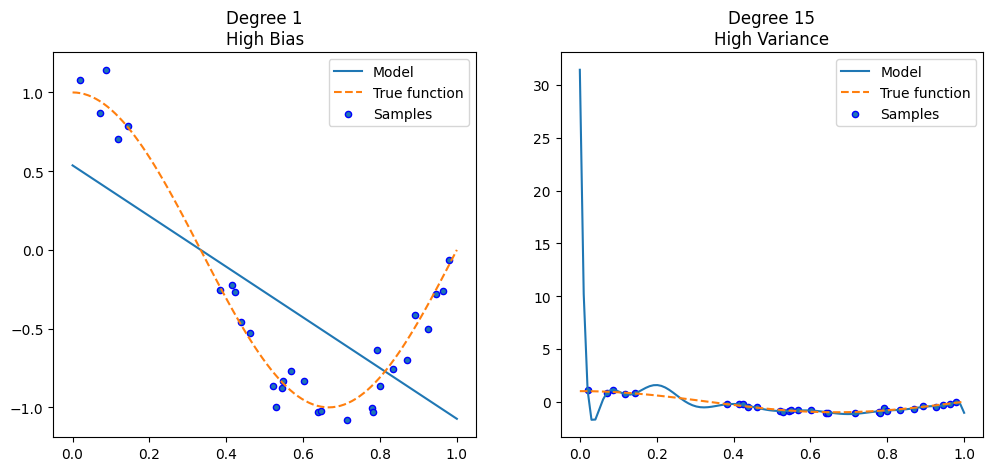

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# 1. Generate Non-Linear Synthetic Data
np.random.seed(0)
def true_fun(X): return np.cos(1.5 * np.pi * X)

n_samples = 30
X = np.sort(np.random.rand(n_samples))
y = true_fun(X) + np.random.randn(n_samples) * 0.1

# 2. Compare Models
degrees = [1, 15] # 1 = High Bias (Linear), 15 = High Variance (Overfit)

plt.figure(figsize=(12, 5))
for i, degree in enumerate(degrees):
    ax = plt.subplot(1, 2, i + 1)

    # Fit model
    polynomial_features = PolynomialFeatures(degree=degree, include_bias=False)
    linear_regression = LinearRegression()
    pipeline = make_pipeline(polynomial_features, linear_regression)
    pipeline.fit(X[:, np.newaxis], y)

    # Plotting
    X_test = np.linspace(0, 1, 100)
    plt.plot(X_test, pipeline.predict(X_test[:, np.newaxis]), label="Model")
    plt.plot(X_test, true_fun(X_test), label="True function", linestyle='--')
    plt.scatter(X, y, edgecolor='b', s=20, label="Samples")
    plt.title(f"Degree {degree}\n{'High Bias' if degree==1 else 'High Variance'}")
    plt.legend(loc="best")

plt.show()

### 8.26 Summary Table: Bias vs. Variance

| Feature | High Bias (Underfitting) | High Variance (Overfitting) |
| :--- | :--- | :--- |
| **Model Complexity** | Too Simple | Too Complex |
| **Training Error** | High | Low (Memorized) |
| **Testing Error** | High | High |
| **Cause** | Missing patterns in data | Picking up noise as patterns |
| **Solution** | Add features, use complex models | Add data, Regularization, Pruning |



**Q: What is the 'Bias-Variance Tradeoff'?**
**A:** It is the challenge of finding the sweet spot where we minimize both types of error. As we increase model complexity, Bias decreases but Variance increases. We want the complexity level that minimizes the total error.

**Q: If your model has 99% training accuracy but 70% test accuracy, what is the problem?**
**A:** This is a clear case of **High Variance (Overfitting)**. The model has memorized the training set but cannot generalize to new data.

**Q: How does 'Regularization' help with this tradeoff?**
**A:** Regularization (like Lasso or Ridge) adds a penalty for complexity. This slightly increases Bias but significantly reduces Variance, often leading to a better total error.

**Q: How do you fix High Bias?**
**A:** Increase model complexity (e.g., use a deeper tree, add polynomial features), or use more features ($X$).

**Q: How do you fix High Variance?**
**A:** Add more training data, use Regularization (L1/L2), or use Ensemble methods like Random Forest (which averages out variance).

**Q: What is the relationship between K-fold Cross Validation and Variance?**
**A:** Cross-validation helps us estimate the variance of a model by seeing how much the performance changes across different data subsets.

## 8.23 Deep Dive: How to Reduce Bias (Fixing Underfitting)

Bias occurs when the model is too restricted to see the pattern. To reduce it, we must **increase model capacity**.

### 1. Increasing Model Complexity (Polynomial Expansion)
If a linear model ($y = w_1x + b$) fails to capture a curve, we add higher-order terms.
**Math:** $y = w_1x + w_2x^2 + ... + w_nx^n + b$

### 2. Adding Features
Adding more dimensions ($X$) gives the model more 'clues'.
**Intuition:** If you can't predict house prices with just 'Square Feet' (High Bias), add 'Neighborhood' and 'Year Built'.

### 3. Reducing Regularization
Regularization ($\\alpha$) penalizes complexity. To reduce bias, we lower $\\alpha$ to let the weights move more freely.
**Math:** $\\text{Minimize } [MSE + \\alpha\\sum w^2] \\rightarrow$ if $\\alpha \\to 0$, we return to standard OLS (Lower Bias).

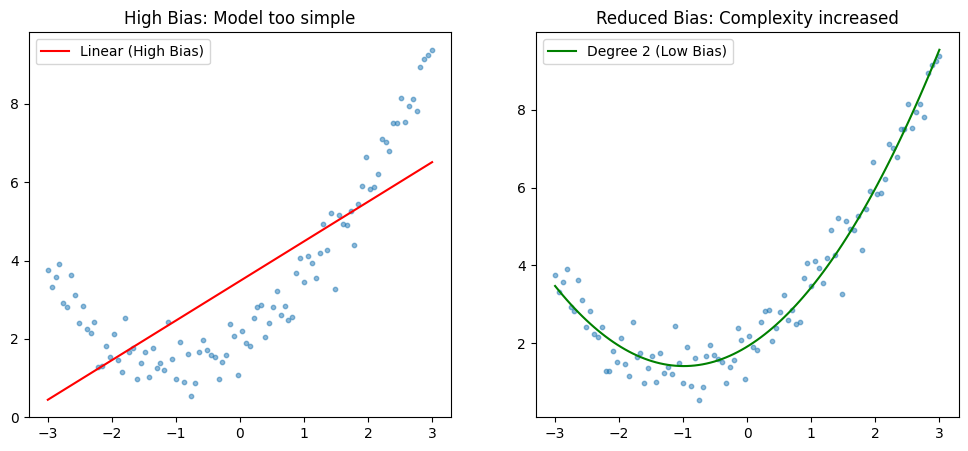

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Data with a clear curve
np.random.seed(42)
X_bias = np.linspace(-3, 3, 100).reshape(-1, 1)
y_bias = 0.5 * X_bias**2 + X_bias + 2 + np.random.randn(100, 1) * 0.5

plt.figure(figsize=(12, 5))

# Case 1: High Bias (Linear Model)
model_linear = LinearRegression().fit(X_bias, y_bias)
plt.subplot(1, 2, 1)
plt.scatter(X_bias, y_bias, s=10, alpha=0.5)
plt.plot(X_bias, model_linear.predict(X_bias), color='red', label='Linear (High Bias)')
plt.title("High Bias: Model too simple")
plt.legend()

# Case 2: Reduced Bias (Polynomial Degree 2)
model_poly = make_pipeline(PolynomialFeatures(2), LinearRegression()).fit(X_bias, y_bias)
plt.subplot(1, 2, 2)
plt.scatter(X_bias, y_bias, s=10, alpha=0.5)
plt.plot(X_bias, model_poly.predict(X_bias), color='green', label='Degree 2 (Low Bias)')
plt.title("Reduced Bias: Complexity increased")
plt.legend()

plt.show()

## 8.24 Deep Dive: How to Reduce Variance (Fixing Overfitting)

Variance occurs when the model is too sensitive to noise. To reduce it, we must **constrain the model**.

### 1. Regularization (Ridge & Lasso)
Regularization adds a penalty to the cost function to keep weights ($w$) small.
**Ridge (L2) Formula:** $J(w) = MSE + \\alpha \\sum_{j=1}^{n} w_j^2$
**Effect:** Large weights are punished heavily (squared), forcing the model to be smoother.

### 2. More Training Data
As $N \\to \\infty$, the influence of individual noisy outliers decreases. The model is forced to learn the global trend rather than local noise.

### 3. Pruning and Early Stopping
In Decision Trees, 'Pruning' cuts off branches that provide little power. In Neural Networks, 'Early Stopping' halts training before the model starts memorizing the noise.

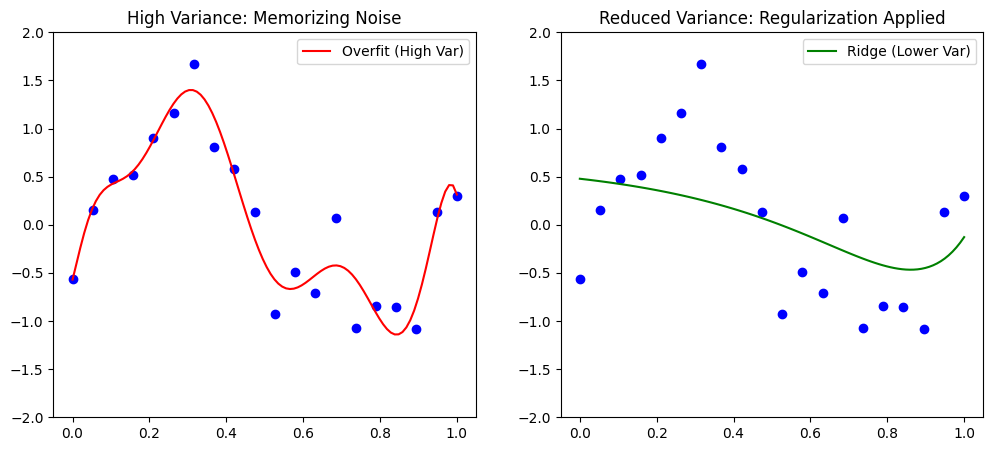

In [38]:
from sklearn.linear_model import Ridge

# Data with significant noise
X_var = np.linspace(0, 1, 20).reshape(-1, 1)
y_var = np.sin(2 * np.pi * X_var) + np.random.normal(0, 0.4, X_var.shape)

# High complexity model (Degree 10)
poly = PolynomialFeatures(10)
X_poly = poly.fit_transform(X_var)

plt.figure(figsize=(12, 5))

# Case 1: High Variance (No Regularization)
model_overfit = LinearRegression().fit(X_poly, y_var)
plt.subplot(1, 2, 1)
plt.scatter(X_var, y_var, color='blue')
X_plot = np.linspace(0, 1, 100).reshape(-1, 1)
plt.plot(X_plot, model_overfit.predict(poly.transform(X_plot)), color='red', label='Overfit (High Var)')
plt.ylim(-2, 2)
plt.title("High Variance: Memorizing Noise")
plt.legend()

# Case 2: Reduced Variance (Ridge Regularization)
model_ridge = Ridge(alpha=1.0).fit(X_poly, y_var)
plt.subplot(1, 2, 2)
plt.scatter(X_var, y_var, color='blue')
plt.plot(X_plot, model_ridge.predict(poly.transform(X_plot)), color='green', label='Ridge (Lower Var)')
plt.ylim(-2, 2)
plt.title("Reduced Variance: Regularization Applied")
plt.legend()

plt.show()

## Topic 9: Deep Dive into Underfitting & Overfitting

### 9.1 The Mathematical Theory: Bias-Variance Decomposition

Any expected error of a machine learning model at a point $x$ can be decomposed into three components. If we assume the true relationship is $y = f(x) + \epsilon$, where $\epsilon$ is noise with mean 0 and variance $\sigma^2$, the **Expected Mean Squared Error (MSE)** is:

$$E[(y - \hat{f}(x))^2] = \text{Bias}[\hat{f}(x)]^2 + \text{Variance}[\hat{f}(x)] + \sigma^2$$

1.  **Bias ($E[\hat{f}(x)] - f(x)$):** The difference between the average prediction of our model and the correct value. High bias $\rightarrow$ Underfitting.
2.  **Variance ($E[\hat{f}(x)^2] - (E[\hat{f}(x)])^2$):** How much the predictions for a given point vary between different realizations of the model. High variance $\rightarrow$ Overfitting.
3.  **Irreducible Error ($\sigma^2$):** The noise in the data itself. No model can predict this.

### 9.2 Manual Calculation Example

Imagine we want to predict a value where the **True Value ($f(x)$) = 10**.

**Scenario A: High Bias (Underfitting)**
Suppose we train 3 models. Because the model is too simple, they all predict roughly the same (wrong) thing:
Predictions: $[6, 6.1, 5.9]$
- **Average Prediction:** $6.0$
- **Bias:** $6.0 - 10 = -4.0$ (High Bias)
- **Variance:** Very low (predictions are consistent but wrong).

**Scenario B: High Variance (Overfitting)**
Suppose we train 3 models. They are so sensitive to noise that their predictions swing wildly:
Predictions: $[10, 14, 6]$
- **Average Prediction:** $(10+14+6)/3 = 10.0$
- **Bias:** $10.0 - 10 = 0$ (Low Bias - on average it is correct!)
- **Variance:** $( (10-10)^2 + (14-10)^2 + (6-10)^2 ) / 3 = (0 + 16 + 16)/3 = 10.66$ (High Variance).

### 9.3 Visualizing with Learning Curves

A **Learning Curve** plots the training and validation error against the **training set size**. It is the most powerful tool for diagnosing these issues.

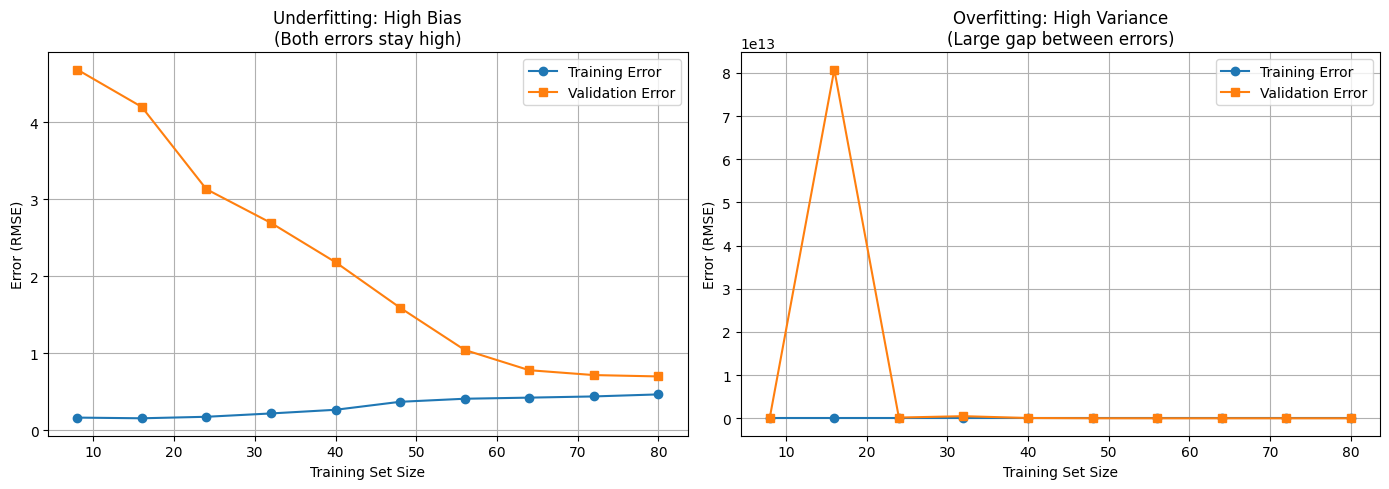

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

def plot_learning_curve(model, title, X, y):
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=5, scoring='neg_mean_squared_error',
        train_sizes=np.linspace(0.1, 1.0, 10)
    )

    # Convert negative MSE to positive RMSE
    train_mean = np.sqrt(-np.mean(train_scores, axis=1))
    test_mean = np.sqrt(-np.mean(test_scores, axis=1))

    plt.plot(train_sizes, train_mean, 'o-', label="Training Error")
    plt.plot(train_sizes, test_mean, 's-', label="Validation Error")
    plt.title(title)
    plt.xlabel("Training Set Size")
    plt.ylabel("Error (RMSE)")
    plt.legend(loc="best")
    plt.grid(True)

# Generate synthetic data
np.random.seed(42)
X_curve = np.sort(np.random.rand(100, 1), axis=0)
y_curve = np.sin(2 * np.pi * X_curve).ravel() + np.random.randn(100) * 0.2

plt.figure(figsize=(14, 5))

# 1. Underfitting (Linear model on Sin wave)
plt.subplot(1, 2, 1)
plot_learning_curve(LinearRegression(), "Underfitting: High Bias\n(Both errors stay high)", X_curve, y_curve)

# 2. Overfitting (High degree polynomial)
plt.subplot(1, 2, 2)
overfit_model = make_pipeline(PolynomialFeatures(degree=15), LinearRegression())
plot_learning_curve(overfit_model, "Overfitting: High Variance\n(Large gap between errors)", X_curve, y_curve)

plt.tight_layout()
plt.show()

### 9.4 How to Fix Them: A Practical Checklist

| To Fix Underfitting (High Bias) | To Fix Overfitting (High Variance) |
| :--- | :--- |
| **1. Increase Complexity:** Use a more complex model (e.g., move from Linear to Non-linear). | **1. Simplify Model:** Reduce the number of parameters or features. |
| **2. Feature Engineering:** Add more relevant features to $X$. | **2. Regularization:** Add L1 (Lasso) or L2 (Ridge) penalties. |
| **3. Decrease Regularization:** Lower the values of $\alpha$ or $\lambda$. | **3. More Data:** Collecting more samples helps the model ignore noise. |
| **4. Train Longer:** In iterative models (like Neural Nets), allow more epochs. | **4. Early Stopping:** Stop training when validation error starts to rise. |

## 9.5 Fixing Overfitting: Regularization (L2 & L1)

Regularization adds a **penalty** to the loss function to prevent the model's coefficients ($w$) from becoming too large (which usually causes high variance).

### A. Ridge Regression (L2 Regularization)
**Theory:** It adds the 'Square of Magnitude' of coefficients as a penalty term.
**Formula:**
$$J(w) = MSE + \alpha \sum_{j=1}^{n} w_j^2$$
**Intuition:** It forces the weights to be small, but they never reach zero. It shrinks all coefficients effectively.

### B. Lasso Regression (L1 Regularization)
**Theory:** It adds the 'Absolute Value' of coefficients as a penalty term.
**Formula:**
$$J(w) = MSE + \alpha \sum_{j=1}^{n} |w_j|$$
**Intuition:** It can force some weights to become **exactly zero**. This performs **feature selection** by removing useless noise.

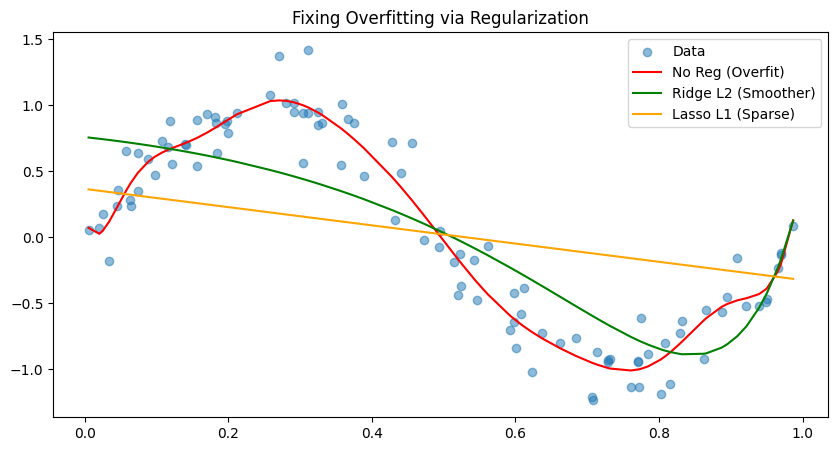

In [33]:
from sklearn.linear_model import Ridge, Lasso

# Using the overfit data X_curve, y_curve from before
poly = PolynomialFeatures(degree=15)
X_poly = poly.fit_transform(X_curve)

# 1. No Regularization (Standard OLS)
model_ols = LinearRegression().fit(X_poly, y_curve)

# 2. Ridge (L2) - Penalty alpha=1.0
model_ridge = Ridge(alpha=1.0).fit(X_poly, y_curve)

# 3. Lasso (L1) - Penalty alpha=0.1
model_lasso = Lasso(alpha=0.1).fit(X_poly, y_curve)

plt.figure(figsize=(10, 5))
plt.scatter(X_curve, y_curve, alpha=0.5, label="Data")
plt.plot(X_curve, model_ols.predict(X_poly), label="No Reg (Overfit)", color='red')
plt.plot(X_curve, model_ridge.predict(X_poly), label="Ridge L2 (Smoother)", color='green')
plt.plot(X_curve, model_lasso.predict(X_poly), label="Lasso L1 (Sparse)", color='orange')
plt.title("Fixing Overfitting via Regularization")
plt.legend()
plt.show()

## 9.6 Fixing Underfitting: Increasing Complexity

If a model is underfitting, it lacks the 'capacity' to represent the data. We fix this by increasing the degree of the polynomial or adding features.

### The Math of Polynomial Expansion
If we have a single feature $x$, and the relationship is curved, a linear model $y = w_0 + w_1x$ will fail (High Bias). We expand $x$ into higher dimensions:
$$y = w_0 + w_1x + w_2x^2 + w_3x^3 + ...$$

**Visual Logic:**
1. **Degree 1:** A straight line (Cannot represent a U-shape).
2. **Degree 2:** A parabola (Can represent a single curve).
3. **Degree 3+:** Can represent complex oscillations.

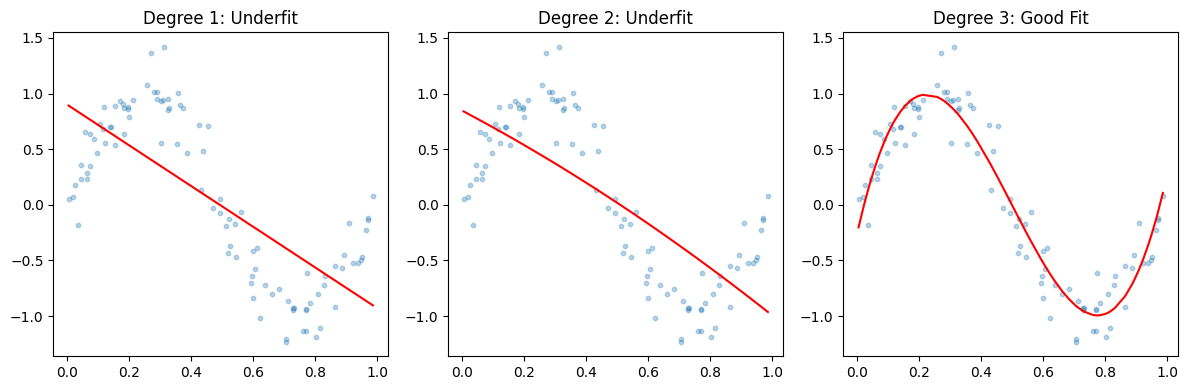

In [34]:
plt.figure(figsize=(12, 4))

degrees = [1, 2, 3]
for i, d in enumerate(degrees):
    plt.subplot(1, 3, i+1)
    model = make_pipeline(PolynomialFeatures(d), LinearRegression())
    model.fit(X_curve, y_curve)
    plt.scatter(X_curve, y_curve, s=10, alpha=0.3)
    plt.plot(X_curve, model.predict(X_curve), color='red')
    plt.title(f"Degree {d}: {'Underfit' if d < 3 else 'Good Fit'}")

plt.tight_layout()
plt.show()

## 9.7 The Math of Regularization: Why it works

When a model overfits, its coefficients ($w$) usually explode to very large values to try and touch every single noisy data point. Regularization adds a constraint to the optimization problem.

### Geometric Intuition
*   **L2 (Ridge) Constraint:** $\|w\|_2^2 \leq t$. This represents a **Circle**. The solution is where the MSE loss contour touches this circle. It shrinks weights toward zero but rarely makes them exactly zero.
*   **L1 (Lasso) Constraint:** $\|w\|_1 \leq t$. This represents a **Diamond**. Because the diamond has sharp corners on the axes, the loss contour is likely to hit a corner, forcing the coefficient for a feature to be **exactly 0**.

### Impact on Model Complexity
| Method | Math Goal | Resulting Model |
| :--- | :--- | :--- |
| **OLS (No Reg)** | $\min MSE$ | Complex, wiggly, high variance |
| **Ridge (L2)** | $\min (MSE + \alpha w^2)$ | Smooth, stable, handles multicollinearity |
| **Lasso (L1)** | $\min (MSE + \alpha |w|)$ | Sparse (removes useless features) |

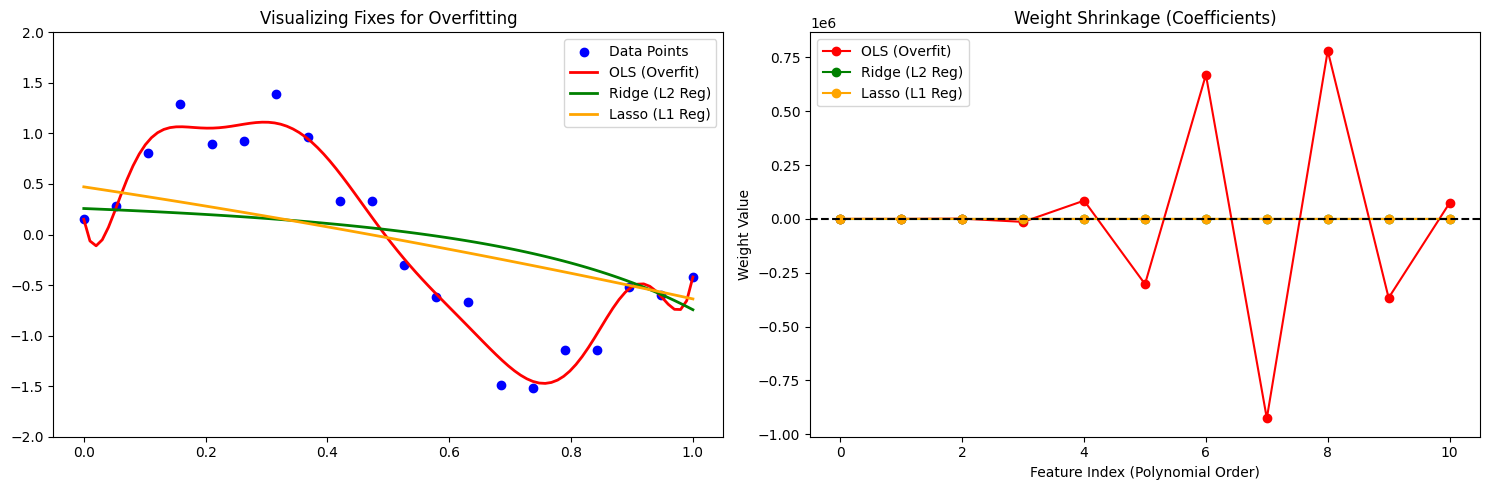

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# 1. Setup Data with a clear 'signal' and 'noise'
np.random.seed(42)
X_val = np.linspace(0, 1, 20).reshape(-1, 1)
y_val = np.sin(2 * np.pi * X_val).ravel() + np.random.normal(0, 0.3, X_val.shape[0])

# 2. Fit models with Degree 10 Polynomials
poly = PolynomialFeatures(degree=10)
X_poly = poly.fit_transform(X_val)

models = [
    ('OLS (Overfit)', LinearRegression(), 'red'),
    ('Ridge (L2 Reg)', Ridge(alpha=10), 'green'),
    ('Lasso (L1 Reg)', Lasso(alpha=0.1), 'orange')
]

plt.figure(figsize=(15, 5))

# Subplot 1: Predictions
plt.subplot(1, 2, 1)
plt.scatter(X_val, y_val, color='blue', label='Data Points')
X_range = np.linspace(0, 1, 100).reshape(-1, 1)
for name, model, color in models:
    model.fit(X_poly, y_val)
    y_plot = model.predict(poly.transform(X_range))
    plt.plot(X_range, y_plot, label=name, color=color, linewidth=2)
plt.ylim(-2, 2)
plt.title("Visualizing Fixes for Overfitting")
plt.legend()

# Subplot 2: Coefficient Magnitude (The 'Why')
plt.subplot(1, 2, 2)
for name, model, color in models:
    plt.plot(model.coef_, 'o-', label=name, color=color)
plt.axhline(0, color='black', linestyle='--')
plt.title("Weight Shrinkage (Coefficients)")
plt.xlabel("Feature Index (Polynomial Order)")
plt.ylabel("Weight Value")
plt.legend()

plt.tight_layout()
plt.show()

## 9.8 Fixing Underfitting with Feature Engineering

Underfitting is often a result of **Linearity Bias**. If the data is nonlinear, no amount of data will fix a linear model. We must change the **Feature Representation**.

### Interaction Terms & Polynomials
If $x_1$ and $x_2$ are features, we can create interaction terms like $x_1 \times x_2$. This allows the model to learn that the effect of $x_1$ depends on $x_2$.

### Manual Calculation of Polynomial Expansion
Input $X = [2]$
Degree 2 Expansion: $[1, x, x^2] \rightarrow [1, 2, 4]$

By feeding $[1, 2, 4]$ into a Linear Regression model, the model effectively learns a curve $y = w_0(1) + w_1(2) + w_2(4)$, even though the math of the optimization is still linear.

# Topic 10: Cross Validation (The 'Reliability' Check)

## 10.1 Why Train-Test Split is not Enough?
Normally, we split data once (e.g., 80/20). But what if the 20% we chose for testing contains all the easiest examples? Our accuracy might be 95%. What if it contains all the hardest outliers? It might be 80%.

**The Problem:** A single split gives a *point estimate* of performance, but it doesn't tell us how much that performance varies depending on the data samples.

## 10.2 What is Cross Validation?
Cross Validation is a resampling procedure used to evaluate machine learning models on a limited data sample.

### The K-Fold Logic:
1.  **Split** the dataset into $K$ equal "folds" (parts).
2.  **Iterate** $K$ times:
    *   Use 1 fold as the **Validation Set**.
    *   Use the remaining $K-1$ folds as the **Training Set**.
3.  **Average** the $K$ results to get the final performance metric.

### Mathematical Intuition
If $E_i$ is the error on the $i$-th fold, the Cross-Validation Error is:
$$CV_{(K)} = \frac{1}{K} \sum_{i=1}^{K} E_i$$

We also look at the **Standard Deviation** of these errors.
*   **Low Std Dev:** The model is stable.
*   **High Std Dev:** The model is very sensitive to which data it sees (High Variance).

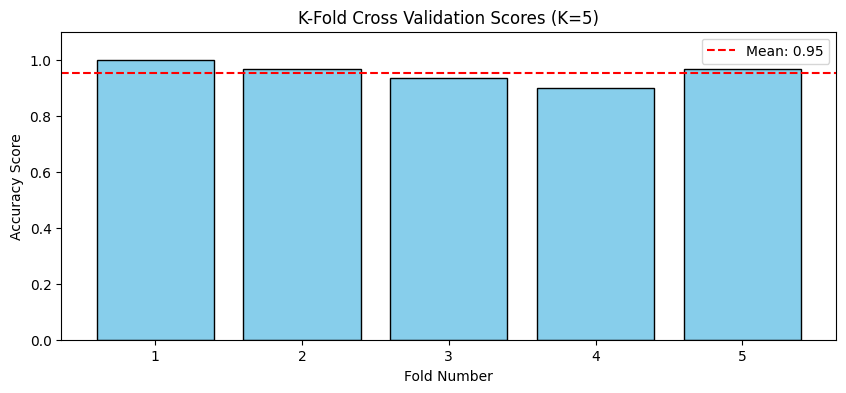

Scores per fold: [1.         0.96666667 0.93333333 0.9        0.96666667]
Average Accuracy: 0.9533
Standard Deviation (Stability): 0.0340


In [39]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

# 1. Load Data
iris = load_iris()
X_cv, y_cv = iris.data, iris.target

# 2. Define Model
model = DecisionTreeClassifier(max_depth=3, random_state=42)

# 3. K-Fold (K=5)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X_cv, y_cv, cv=kf)

# Visualizing the scores per fold
plt.figure(figsize=(10, 4))
plt.bar(range(1, 6), scores, color='skyblue', edgecolor='black')
plt.axhline(y=scores.mean(), color='red', linestyle='--', label=f'Mean: {scores.mean():.2f}')
plt.title("K-Fold Cross Validation Scores (K=5)")
plt.xlabel("Fold Number")
plt.ylabel("Accuracy Score")
plt.ylim(0, 1.1)
plt.legend()
plt.show()

print(f"Scores per fold: {scores}")
print(f"Average Accuracy: {scores.mean():.4f}")
print(f"Standard Deviation (Stability): {scores.std():.4f}")

## 10.3 Advanced Validation Techniques

### A. Stratified K-Fold (Best for Classification)
If you have a dataset where 90% are 'Healthy' and 10% are 'Sick', a random split might result in a fold with 0% 'Sick' samples.
**Stratified K-Fold** ensures that each fold maintains the same percentage of classes as the original dataset.

### B. Leave-One-Out (LOOCV)
$K = N$ (Number of samples). You train on all points except one.
*   **Pro:** Maximum data used for training.
*   **Con:** Computationally expensive; very slow for large data.

### C. Time Series Split
In time-ordered data, we cannot use 'Future' data to predict the 'Past'.
**Correct Approach:**
*   Fold 1: Train[Jan], Test[Feb]
*   Fold 2: Train[Jan, Feb], Test[Mar]
*   Fold 3: Train[Jan, Feb, Mar], Test[Apr]

In [40]:
from sklearn.model_selection import TimeSeriesSplit

# 1. Create dummy time series data
X_time = np.arange(10).reshape(-1, 1)

# 2. Setup Time Series Split
tss = TimeSeriesSplit(n_splits=3)

print("Time Series Split Logic (Indices):")
for i, (train_index, test_index) in enumerate(tss.split(X_time)):
    print(f"Fold {i+1}: Train={train_index}, Test={test_index}")

# 3. Stratified K-Fold Example
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
strat_scores = cross_val_score(model, X_cv, y_cv, cv=skf)
print(f"\nStratified Mean Accuracy: {strat_scores.mean():.4f}")

Time Series Split Logic (Indices):
Fold 1: Train=[0 1 2 3], Test=[4 5]
Fold 2: Train=[0 1 2 3 4 5], Test=[6 7]
Fold 3: Train=[0 1 2 3 4 5 6 7], Test=[8 9]

Stratified Mean Accuracy: 0.9467


## 10.4 Summary Table: When to use what?

| Method | Best For | Level of Bias/Variance |
| :--- | :--- | :--- |
| **Train-Test Split** | Huge datasets where speed is priority | High Variance |
| **K-Fold (K=5/10)** | General purpose ML | Balanced |
| **Stratified K-Fold**| Imbalanced Classification | Balanced & Representative |
| **LOOCV** | Very small datasets (< 50 samples) | Low Bias, High Variance |
| **Time Series Split**| Stocks, Weather, Forecasting | Essential for temporal order |

## 10.5 K-Fold Cross Validation: The Gold Standard

### The Mathematical Foundation
If we have a dataset $D$ and we split it into $K$ folds, the model is trained $K$ times. Let $E_i$ be the error (e.g., MSE or 1-Accuracy) measured on the $i$-th fold. The **Cross-Validation Error** is the average:

$$CV_{(K)} = \frac{1}{K} \sum_{i=1}^{K} E_i$$

### Why $K=10$?
- **Small K (e.g., 2):** High Bias (we only use 50% of data for training, so the model underperforms).
- **Large K (e.g., N):** Low Bias but High Variance and extremely slow computation.
- **$K=10$** is the empirical 'sweet spot' for balancing computation and reliability.

### 10.6 Stratified K-Fold (Math of Proportions)
In classification, if class $C_1$ represents 10% of data, Stratified CV ensures:
$$\frac{n_{i, C_1}}{n_i} \approx \frac{N_{C_1}}{N}$$
Where $n_i$ is the size of fold $i$. This is critical for imbalanced datasets like Fraud Detection.

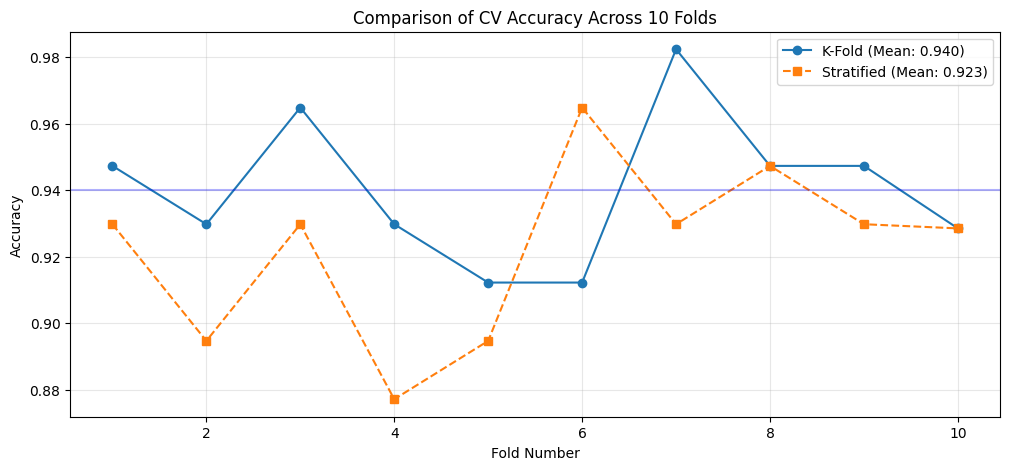

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_breast_cancer

# Load Dataset
data = load_breast_cancer()
X, y = data.data, data.target
model = DecisionTreeClassifier(max_depth=3, random_state=42)

# 1. K-Fold Implementation
kf = KFold(n_splits=10, shuffle=True, random_state=42)
kf_scores = cross_val_score(model, X, y, cv=kf)

# 2. Stratified K-Fold Implementation
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
skf_scores = cross_val_score(model, X, y, cv=skf)

# Visualization of Variance across Folds
plt.figure(figsize=(12, 5))
plt.plot(range(1, 11), kf_scores, 'o-', label=f'K-Fold (Mean: {kf_scores.mean():.3f})')
plt.plot(range(1, 11), skf_scores, 's--', label=f'Stratified (Mean: {skf_scores.mean():.3f})')
plt.axhline(y=kf_scores.mean(), color='blue', alpha=0.3)
plt.title("Comparison of CV Accuracy Across 10 Folds")
plt.xlabel("Fold Number")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 10.7 Specialized CV Methods

### 1. Leave-One-Out (LOOCV)
Every single observation acts as a test set once.
- **Math:** $K = N$
- **Formula:** $CV_{(N)} = \frac{1}{N} \sum_{i=1}^{N} L(y_i, \hat{f}^{-i}(x_i))$
- **Best for:** Small datasets ($N < 50$).

### 2. Time Series Split (Forward Chaining)
Prevents 'Look-ahead bias'. You can only train on the past to predict the future.
- **Logic:**
  - Split 1: [1] vs [2]
  - Split 2: [1, 2] vs [3]
  - Split 3: [1, 2, 3] vs [4]

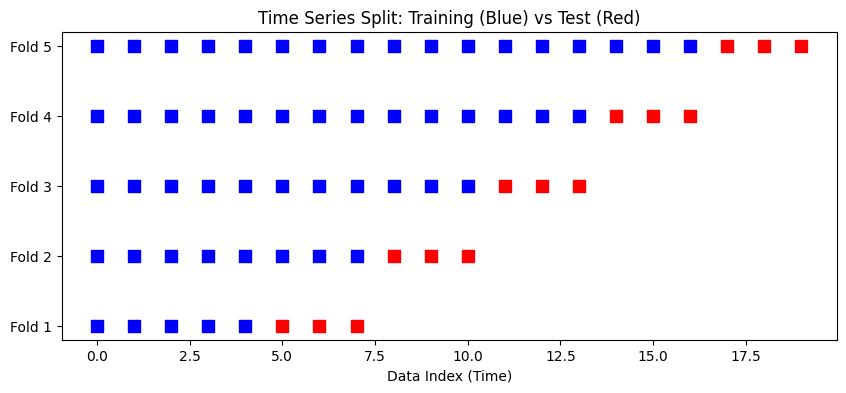

In [44]:
from sklearn.model_selection import TimeSeriesSplit

# Visualizing Time Series Split Logic
tscv = TimeSeriesSplit(n_splits=5)
X_dummy = np.zeros(20)

plt.figure(figsize=(10, 4))
for i, (train, test) in enumerate(tscv.split(X_dummy)):
    plt.scatter(train, [i] * len(train), c='blue', marker='s', s=80)
    plt.scatter(test, [i] * len(test), c='red', marker='s', s=80)

plt.yticks(range(5), [f'Fold {i+1}' for i in range(5)])
plt.title("Time Series Split: Training (Blue) vs Test (Red)")
plt.xlabel("Data Index (Time)")
plt.show()

## 10.8 Summary Checklist for Interviews

- **Q: Why use CV instead of Train-Test?** A: To reduce the variance of the performance estimate and ensure every point is used for validation.
- **Q: What is the risk of LOOCV?** A: High computational cost and high variance of the error estimate (since folds are highly correlated).
- **Q: How do you handle Time Series?** A: Never use random K-Fold. Use `TimeSeriesSplit` to respect temporal order.
- **Q: Formula for CV Error?** A: $CV_K = \frac{1}{K} \sum MSE_i$.


# Topic 11: Evaluation Metrics

## 11.1 Why Accuracy is Not Enough?

Imagine you are building a model to detect a rare disease that affects 1% of the population. If your model simply predicts "Healthy" for every single person, it will be **99% accurate**.

However, it is **0% useful** because it missed every single sick patient. This is why we need more nuanced metrics than just accuracy, especially for imbalanced datasets.

---

## 11.2 The Confusion Matrix ⭐⭐⭐⭐⭐

The Confusion Matrix is the foundation for all classification metrics. It breaks down predictions into four categories:

| | **Predicted Positive** | **Predicted Negative** |
|---|---:|---:|
| **Actual Positive** | **TP** (True Positive) | **FN** (False Negative) |
| **Actual Negative** | **FP** (False Positive) | **TN** (True Negative) |

### Definitions:
*   **TP (True Positive):** You predicted sick, and they are sick. (Success)
*   **TN (True Negative):** You predicted healthy, and they are healthy. (Success)
*   **FP (False Positive):** You predicted sick, but they are healthy. (**Type I Error** - False Alarm)
*   **FN (False Negative):** You predicted healthy, but they are sick. (**Type II Error** - Missed Case)

---

## 11.3 Classification Metrics: The Formulas

### 1. Accuracy
Overall correctness of the model.
$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

### 2. Precision (Exactness)
"Of all people we predicted as sick, how many actually were?"
$$\text{Precision} = \frac{TP}{TP + FP}$$

### 3. Recall / Sensitivity (Completeness)
"Of all the people who were actually sick, how many did we catch?"
$$\text{Recall} = \frac{TP}{TP + FN}$$

### 4. Specificity
"Of all the healthy people, how many did we correctly identify as healthy?"
$$\text{Specificity} = \frac{TN}{TN + FP}$$

### 5. F1-Score
The harmonic mean of Precision and Recall. Use this when you want a balance between the two.
$$F1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$
```

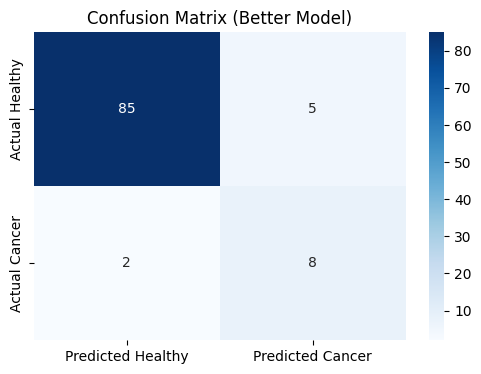

Lazy Model Accuracy: 90.0%
Better Model Accuracy: 93.0%

Full Report for Better Model:
              precision    recall  f1-score   support

     Healthy       0.98      0.94      0.96        90
      Cancer       0.62      0.80      0.70        10

    accuracy                           0.93       100
   macro avg       0.80      0.87      0.83       100
weighted avg       0.94      0.93      0.93       100



In [45]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Scenario: 100 Patients (10 have Cancer, 90 are Healthy)
y_true = np.array([1]*10 + [0]*90)

# Model A: "The Lazy Model" (Predicts everyone is healthy)
y_pred_lazy = np.zeros(100)

# Model B: "The Better Model" (Caught 8/10 cancer cases, but had 5 false alarms)
y_pred_better = np.array([1]*8 + [0]*2 + [1]*5 + [0]*85)

# 1. Calculate Confusion Matrix
cm = confusion_matrix(y_true, y_pred_better)

# 2. Visualize
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Healthy', 'Predicted Cancer'],
            yticklabels=['Actual Healthy', 'Actual Cancer'])
plt.title("Confusion Matrix (Better Model)")
plt.show()

print(f"Lazy Model Accuracy: {accuracy_score(y_true, y_pred_lazy)*100}%")
print(f"Better Model Accuracy: {accuracy_score(y_true, y_pred_better)*100}%")
print("\nFull Report for Better Model:")
print(classification_report(y_true, y_pred_better, target_names=['Healthy', 'Cancer']))


## 11.4 ROC Curve & AUC

### ROC (Receiver Operating Characteristic)
Plots the **True Positive Rate** (Recall) against the **False Positive Rate** ($1 - \text{Specificity}$) at various threshold settings.

### AUC (Area Under the Curve)
*   **AUC = 1.0:** Perfect model.
*   **AUC = 0.5:** Random guessing (no better than a coin flip).
*   **AUC < 0.5:** The model is doing the opposite of the truth.

## 11.5 Precision-Recall Curve
While ROC curves are great for balanced data, the **Precision-Recall Curve** is much more informative for **imbalanced datasets** (e.g., fraud detection) where the positive class is rare.
```

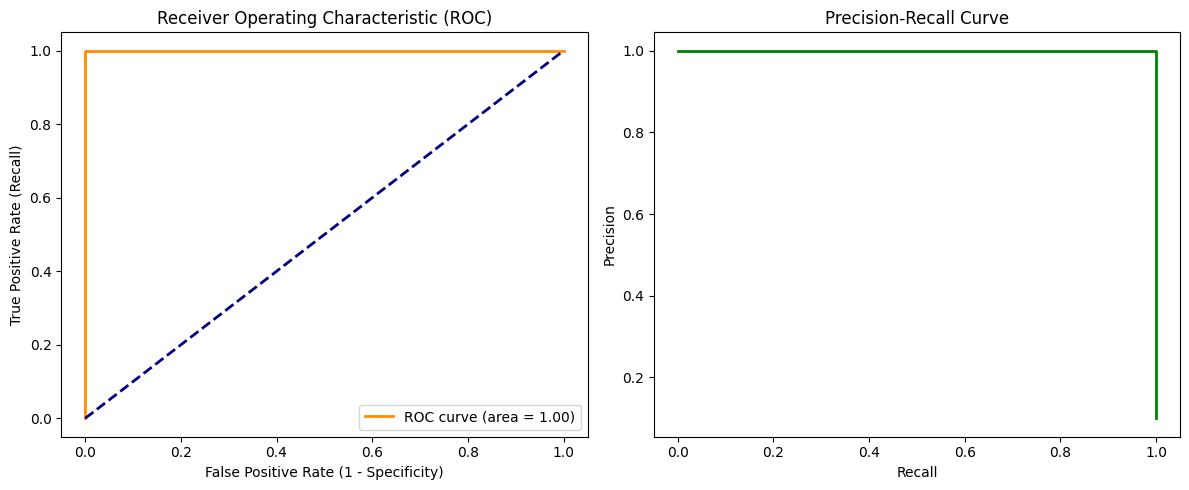

In [46]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# Generate dummy probabilities for our Better Model
y_probs = np.concatenate([np.random.uniform(0.6, 0.9, 10), np.random.uniform(0.1, 0.4, 90)])

fpr, tpr, _ = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(12, 5))

# Subplot 1: ROC Curve
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")

# Subplot 2: Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_true, y_probs)
plt.subplot(1, 2, 2)
plt.plot(recall, precision, color='green', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')

plt.tight_layout()
plt.show()


## 11.6 Regression Metrics

In regression, we don't have "correct" or "incorrect" categories; we have distances from the truth.

### 1. MAE (Mean Absolute Error)
Average magnitude of error in the same units as the target.
$$\text{MAE} = \frac{1}{n} \sum |y - \hat{y}|$$

### 2. MSE (Mean Squared Error)
Squares the errors. Punishes large outliers heavily.
$$\text{MSE} = \frac{1}{n} \sum (y - \hat{y})^2$$

### 3. RMSE (Root Mean Squared Error)
Square root of MSE. Brings the error back to the original unit scale.
$$\text{RMSE} = \sqrt{MSE}$$

### 4. R² Score (Coefficient of Determination)
Percentage of variance explained by the model.
$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}}$$
*   **1.0:** Perfect fit.
*   **0.0:** Baseline model (always predicts the mean).
*   **Negative:** Your model is worse than just predicting the average.

---

## 11.7 Metric Selection Guide

| Goal | Metric to Choose |
| :--- | :--- |
| **Balanced Classification** | Accuracy |
| **Medical Diagnosis (Don't miss a case)** | Recall |
| **Spam Filter (Don't block good emails)** | Precision |
| **Imbalanced Classes** | F1-Score or PR AUC |
| **Regression (Average error matters)** | MAE |
| **Regression (Outliers are dangerous)** | RMSE |

---

## 11.8 Interview Questions

**Q: Why is F1 better than Accuracy for imbalanced data?**
**A:** Accuracy can be high just by predicting the majority class. F1 requires both Precision and Recall to be high, forcing the model to actually identify the minority class correctly.

**Q: What is the difference between Sensitivity and Specificity?**
**A:** Sensitivity is the "True Positive Rate" (how many sick people we found). Specificity is the "True Negative Rate" (how many healthy people we correctly labeled as healthy).

**Q: When would you use MSE instead of MAE?**
**A:** When large errors are particularly undesirable. For example, in bridge engineering, being off by 10cm is much more than 10x worse than being off by 1cm.
```